In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy.spatial.distance import jensenshannon
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings("ignore")

from evaluation import Metrics, Plot

In [2]:
eia = pd.read_csv('../probabilistic/new_trained_results/wevalidate/rnn_eia.csv')

eia_metrics = Metrics('EIA', eia['speed'], eia['power'], eia['preds'])
eia_metrics.print_metrics()

EIA Metrics:
RMSE: 0.1800624870681189
Cross Correlation: 0.8480999678181997
Similarity: 0.6862538878387032
Bias: -0.021574041852969197
RMS Steady: 97.3616047970599
RMS Loss: 80.80075426915528
RMS True: 46.85261987464643
RMS Predicted: 43.50072452055152


## traditional/physics

In [27]:
# trad = pd.read_csv('../probabilistic/new_results/trad_1423_brownian.csv')
trad = pd.read_csv('../probabilistic/new_trained_results/trad_1423.csv')

trad_metrics = Metrics('Physics', trad['speed'], trad['power'], trad['preds'])
trad_plot = Plot('Physics', trad['speed'], trad['power'], trad['preds'])
trad_metrics.print_metrics()
# trad_plot.plot_all()

Physics Metrics:
RMSE: 0.208007215317947
Cross Correlation: 0.786760728098035
Similarity: 0.7308684727334067
Bias: 0.034715616628725125
RMS Steady: 152.4913645788543
RMS Loss: 130.40171541325668
RMS True: 115.71622192601852
RMS Predicted: 124.9322027586275


## probabilistic

In [28]:
# prob = pd.read_csv('../probabilistic/new_results/prob_1423.csv')
prob = pd.read_csv('../probabilistic/new_trained_results/prob_1423.csv')

prob_metrics = Metrics('Probabilistic', prob['speed'], prob['power'], prob['preds'])
prob_plot = Plot('Probabilistic', prob['speed'], prob['power'], prob['preds'])
prob_metrics.print_metrics()
# prob_plot.plot_all()

Probabilistic Metrics:
RMSE: 0.29335547235743836
Cross Correlation: 0.5456732691629113
Similarity: 0.8076817458386948
Bias: -0.003388924838748517
RMS Steady: 152.4913645788543
RMS Loss: 130.40171541325668
RMS True: 115.71622192601852
RMS Predicted: 116.06756499832716


## NQF-RNN (168hrs)

In [29]:
# rnn = pd.read_csv('../probabilistic/new_results/rnn_1423_brownian.csv')
rnn = pd.read_csv('../probabilistic/new_trained_results/rnn_1423_weights.csv')

rnn_metrics = Metrics('RNN 168hr', rnn['speed'], rnn['power'], rnn['preds'])
rnn_plot = Plot('RNN 168hr', rnn['speed'], rnn['power'], rnn['preds'])
rnn_metrics.print_metrics()
# rnn_plot.plot_all()

RNN 168hr Metrics:
RMSE: 0.18918155169134643
Cross Correlation: 0.7986799092811372
Similarity: 0.8031199627362481
Bias: -0.015218358964522078
RMS Steady: 152.4913645788543
RMS Loss: 130.40171541325668
RMS True: 115.71622192601852
RMS Predicted: 110.14982370951985


### Different hour RNNs

In [5]:
rnn12 = pd.read_csv('../probabilistic/new_trained_results/rnn12_1423.csv')
rnn24 = pd.read_csv('../probabilistic/new_trained_results/rnn24_1423.csv')
rnn72 = pd.read_csv('../probabilistic/new_trained_results/rnn72_1423.csv')
rnn168 = pd.read_csv('../probabilistic/new_trained_results/rnn_1423_weights.csv')

In [6]:
# compile all NQF-RNN hours into one csv
df = pd.read_csv('../../data/processed/dataset_14-23.csv')

df['npower'] = df['power'] / np.max(df['power'])
df['rnn12'] = rnn12['preds']
df['rnn24'] = rnn24['preds']
df['rnn72'] = rnn72['preds']
df['rnn168'] = rnn168['preds']

df.to_csv('rnn_models.csv', index=False)

In [9]:
rnn12_metrics = Metrics('RNN 12hr', rnn12['speed'], rnn12['power'], rnn12['preds'])
rnn12_metrics.print_metrics()
print('\n')
rnn24_metrics = Metrics('RNN 24hr', rnn24['speed'], rnn24['power'], rnn24['preds'])
rnn24_metrics.print_metrics()

RNN 12hr Metrics:
RMSE: 0.3202502531062182
Cross Correlation: 0.4642375773124655
Similarity: 0.6249315795568371
Bias: 0.024715718690521197
RMS Steady: 152.4913645788543
RMS Loss: 130.40171541325668
RMS True: 115.71622192601852
RMS Predicted: 121.56934355868815


RNN 24hr Metrics:
RMSE: 0.22805602902464286
Cross Correlation: 0.7815003997325598
Similarity: 0.7501852784193639
Bias: 0.07208042218810215
RMS Steady: 152.4913645788543
RMS Loss: 130.40171541325668
RMS True: 115.71622192601852
RMS Predicted: 135.1264014106232


In [10]:
rnn72_metrics = Metrics('RNN 72hr', rnn72['speed'], rnn72['power'], rnn72['preds'])
rnn72_metrics.print_metrics()
print('\n')
rnn168_metrics = Metrics('RNN 168hr', rnn168['speed'], rnn168['power'], rnn168['preds'])
rnn168_metrics.print_metrics()

RNN 72hr Metrics:
RMSE: 0.20858191675360316
Cross Correlation: 0.7564119185034351
Similarity: 0.8016529355572586
Bias: 0.027370431461146337
RMS Steady: 152.4913645788543
RMS Loss: 130.40171541325668
RMS True: 115.71622192601852
RMS Predicted: 118.1063540357344


RNN 168hr Metrics:
RMSE: 0.18918155169134643
Cross Correlation: 0.7986799092811372
Similarity: 0.8031199627362481
Bias: -0.015218358964522078
RMS Steady: 152.4913645788543
RMS Loss: 130.40171541325668
RMS True: 115.71622192601852
RMS Predicted: 110.14982370951985


### Compile Palouse wind farm data

In [45]:
model = pd.read_csv('../probabilistic/new_trained_results/wevalidate/rnn_eia.csv')
nwpdb = pd.read_csv('../probabilistic/wevalidate_data/nwpdb-HRRR.csv')
pluswind = pd.read_csv('../probabilistic/wevalidate_data/pluswind-HRRR.csv')

model.rename(columns={'preds': 'rnn_preds'}, inplace=True)
model.drop(columns=['npreds'], inplace=True)

nwpdb['time_stamp'] = pd.to_datetime(nwpdb['time_stamp']).astype(str)
nwpdb.rename(columns={'time_stamp': 'datetime', 'power': 'nwpdb'}, inplace=True)
nwpdb.drop(columns=['npower'], inplace=True)

pluswind['time_stamp'] = pd.to_datetime(pluswind['time_stamp']).astype(str)
pluswind.rename(columns={'time_stamp': 'datetime', 'power': 'pluswind'}, inplace=True)
pluswind.drop(columns=['npower'], inplace=True)

# merge all data
model = model.merge(nwpdb, on='datetime', how='left')
model = model.merge(pluswind, on='datetime', how='left')
model = model[['datetime', 'speed', 'power', 'nwpdb', 'pluswind', 'rnn_preds']]

model.to_csv('palouse_results.csv', index=False)

# Conference Paper Figures

In [2]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

In [3]:
# rnn = pd.read_csv('../probabilistic/new_results/rnn_1423_brownian.csv')
rnn = pd.read_csv('../probabilistic/new_trained_results/rnn_1423_weights.csv')

rnn_metrics = Metrics('RNN 168hr', rnn['speed'], rnn['power'], rnn['preds'])
rnn_plot = Plot('RNN 168hr', rnn['speed'], rnn['power'], rnn['preds'])
rnn_metrics.print_metrics()
# rnn_plot.plot_all()

RNN 168hr Metrics:
RMSE: 0.18918155169134643
Cross Correlation: 0.7986799092811377
Similarity: 0.8031199627362481
Bias: -0.015218358964522078
RMS Steady: 152.4913645788543
RMS Loss: 130.40171541325668
RMS True: 115.71622192601852
RMS Predicted: 110.14982370951985


In [4]:
rnn

,datetime,speed,power,npower,preds,npreds
0,2014-07-30 12:00:00,9.416307,222.814,0.912316,117.508934,0.480609
1,2014-07-30 13:00:00,8.168459,193.077,0.790557,140.340240,0.573989
2,2014-07-30 14:00:00,6.081183,166.707,0.682585,138.638260,0.567028
3,2014-07-30 15:00:00,3.644644,135.965,0.556711,98.345110,0.402229
4,2014-07-30 16:00:00,4.062179,103.724,0.424700,58.146960,0.237820
...,...,...,...,...,...,...
82295,2023-12-31 19:00:00,10.002887,14.636,0.059927,80.979120,0.331203
82296,2023-12-31 20:00:00,9.850973,5.243,0.021468,109.854866,0.449304
82297,2023-12-31 21:00:00,9.078698,0.446,0.001826,116.186760,0.475201
82298,2023-12-31 22:00:00,8.771991,0.195,0.000798,104.775790,0.428531


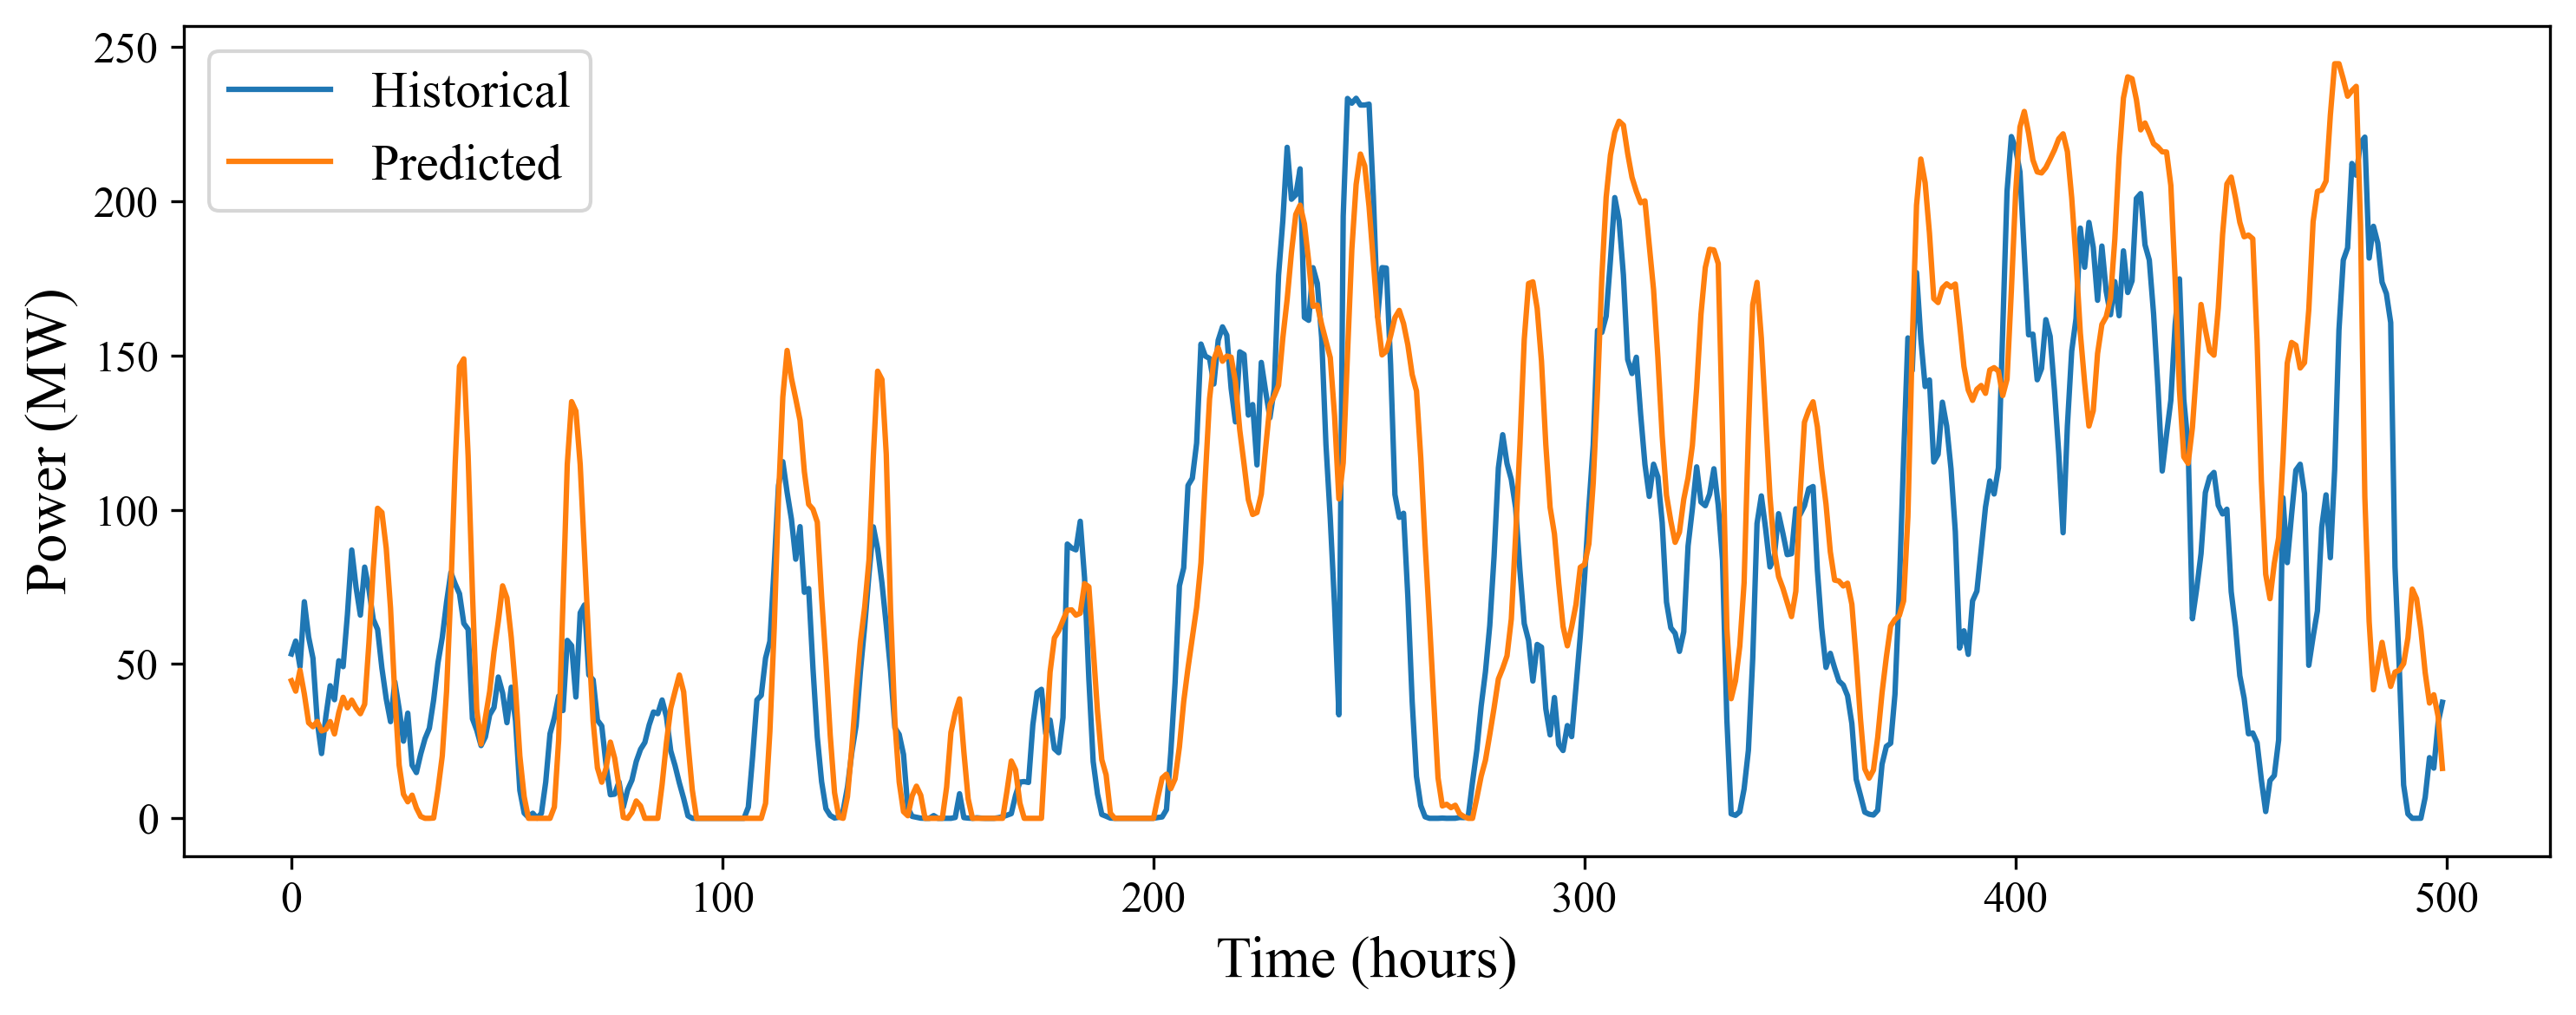

In [6]:
# time series
plt.figure(figsize=(10, 4), dpi=300)
plt.plot(rnn['power'][10200:10700].reset_index(drop=True), label='Historical')
plt.plot(rnn['preds'][10200:10700].reset_index(drop=True), label='Predicted')
# plt.title('NQF-RNN Time Series (Trained on 168 Hours)', fontsize=20)
plt.xlabel('Time (hours)', fontsize=16)
plt.ylabel('Power (MW)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left', fontsize=14)
plt.tight_layout()

plt.savefig('../figures/nqfrnn_time_series.png', bbox_inches='tight', dpi=300)

In [7]:
# power curve density
H_true, _, _ = np.histogram2d(rnn['speed'], rnn['power'], bins=50)
H_pred, _, _ = np.histogram2d(rnn['speed'], rnn['preds'], bins=50)
H_true_norm = H_true / H_true.sum()
H_pred_norm = H_pred / H_pred.sum()
js_div = jensenshannon(H_true_norm.flatten(), H_pred_norm.flatten())  # Value between 0 and 1
similarity = 1 - js_div
match_percentage = np.round(similarity * 100, 2)

# log transform
vals_true = np.log(H_true.T)
vals_true[np.isneginf(vals_true)] = 0
vals_true = vals_true / vals_true.max()
vals_pred = np.log(H_pred.T)
vals_pred[np.isneginf(vals_pred)] = 0
vals_pred = vals_pred / vals_pred.max()
diff = vals_pred - vals_true

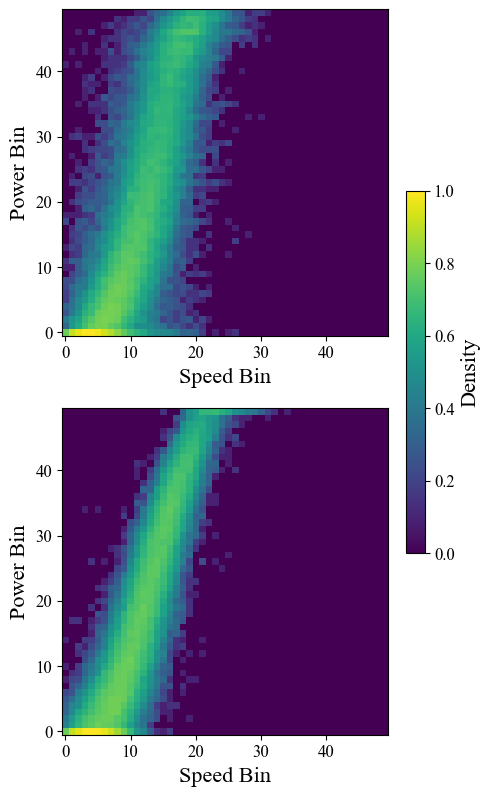

In [ ]:
# pred, hist density plots
fig, axs = plt.subplots(2, 1, figsize=(5, 9.5))

im0 = axs[0].imshow(vals_true, origin='lower', cmap='viridis')
axs[0].set_xlabel("Speed Bin", fontsize=16)
axs[0].set_ylabel("Power Bin", fontsize=16)
axs[0].tick_params(axis='both', which='major', labelsize=12)

im1 = axs[1].imshow(vals_pred, origin='lower', cmap='viridis')
axs[1].set_xlabel("Speed Bin", fontsize=16)
axs[1].set_ylabel("Power Bin", fontsize=16)
axs[1].tick_params(axis='both', which='major', labelsize=12)

fig.subplots_adjust(right=0.85)
cbar = fig.colorbar(im1, ax=axs, orientation='vertical', fraction=0.05)
cbar.set_label('Density', fontsize=16)
cbar.ax.tick_params(labelsize=12)

plt.savefig('../figures/power_densities.png', bbox_inches='tight', dpi=300)

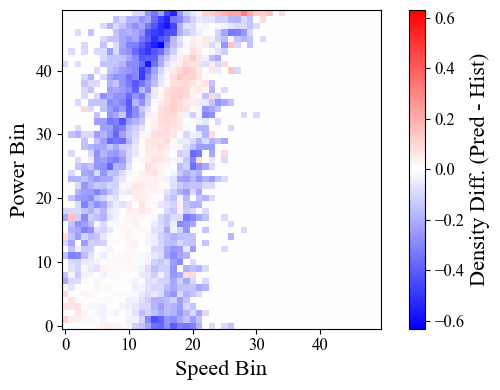

In [ ]:
# density diff plot
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(diff, origin='lower', cmap='bwr', vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)))
ax.set_xlabel("Speed Bin", fontsize=16)
ax.set_ylabel("Power Bin", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Density Diff. (Pred - Hist)", fontsize=16)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig('../figures/power_density_diff.png', bbox_inches='tight', dpi=300)

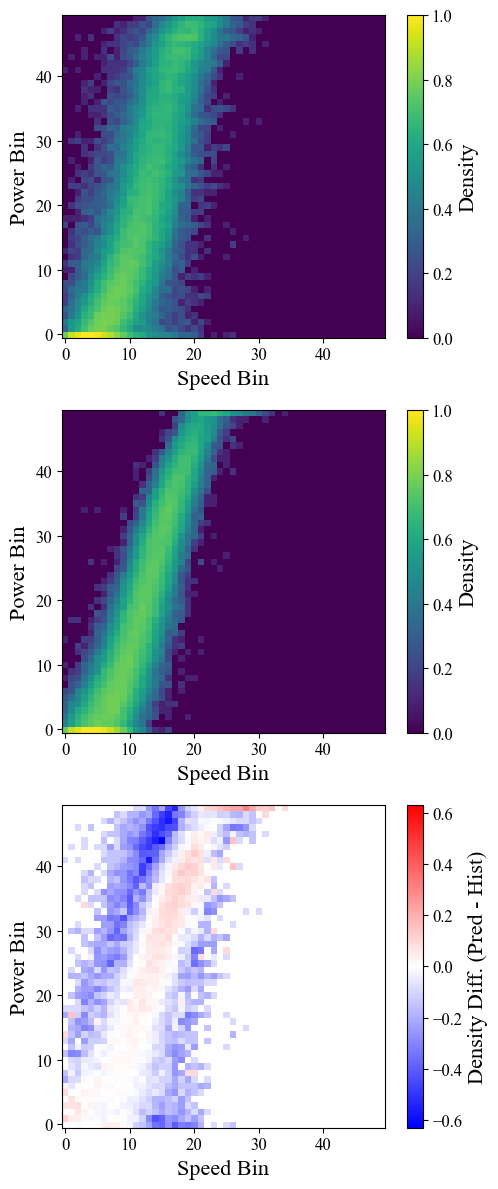

In [ ]:
# power densities (pred, hist, diff)
fig, axs = plt.subplots(3, 1, figsize=(5, 12))

im0 = axs[0].imshow(vals_true, origin='lower', cmap='viridis')
axs[0].set_xlabel("Speed Bin", fontsize=16)
axs[0].set_ylabel("Power Bin", fontsize=16)
axs[0].tick_params(axis='both', which='major', labelsize=12)

im1 = axs[1].imshow(vals_pred, origin='lower', cmap='viridis')
axs[1].set_xlabel("Speed Bin", fontsize=16)
axs[1].set_ylabel("Power Bin", fontsize=16)
axs[1].tick_params(axis='both', which='major', labelsize=12)

im2 = axs[2].imshow(diff, origin='lower', cmap='bwr', vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)))
axs[2].set_xlabel("Speed Bin", fontsize=16)
axs[2].set_ylabel("Power Bin", fontsize=16)
axs[2].tick_params(axis='both', which='major', labelsize=12)

cbar0 = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cbar0.set_label('Density', fontsize=16)
cbar0.ax.tick_params(labelsize=12)

cbar1 = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cbar1.set_label('Density', fontsize=16)
cbar1.ax.tick_params(labelsize=12)

cbar2 = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cbar2.set_label("Density Diff. (Pred - Hist)", fontsize=16)
cbar2.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig('../figures/power_densities_combined_raw.png', bbox_inches='tight', dpi=300)


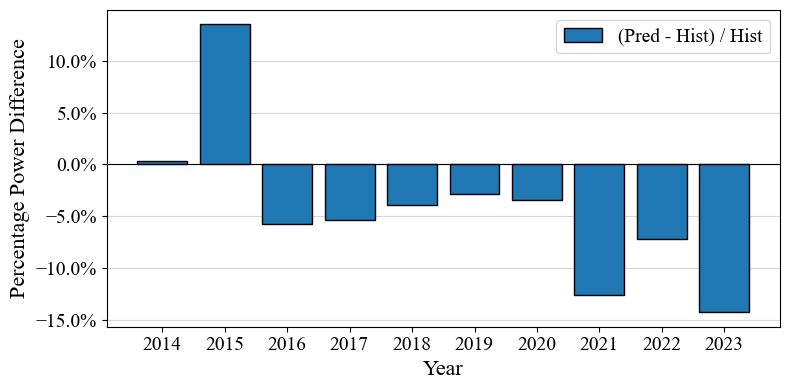

In [ ]:
# 10 year means
power_mean = np.mean(np.array_split(rnn['power'], 10), axis=1)
pred_mean = np.mean(np.array_split(rnn['preds'], 10), axis=1)

plt.figure(figsize=(8, 4))
ax = plt.gca()
plt.bar(np.arange(10), (pred_mean - power_mean) / power_mean, label='(Pred - Hist) / Hist', edgecolor='black', zorder=3)
plt.xlabel('Year', fontsize=16)
plt.xticks(ticks=np.arange(0, 10), labels=[str(2014 + i) for i in range(10)], fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel('Percentage Power Difference', fontsize=16)
plt.legend(fontsize=14)
plt.grid(axis='y', alpha=0.5, zorder=0)
plt.axhline(0, color='black', linewidth=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.tight_layout()

plt.savefig('../figures/annual_power_diff.png', bbox_inches='tight', dpi=300)

In [4]:
i14 = 3678
i15 = 12378
i16 = 20992
i17 = 29716
i18 = 38476
i19 = 47236
i20 = 56020
i21 = 64780
i22 = 73540

In [22]:
# 10 year evaluation metric means for paper revision
def rmse(npower, npreds):
    return float(np.sqrt(np.mean((npower - npreds) ** 2)))

def cross_correlation(npower, npreds):
    return float(np.corrcoef(npower, npreds)[0, 1])

def similarity(speeds, power, preds, bins=50): # power curve similarity
    H_true, _, _ = np.histogram2d(speeds, power, bins=bins)
    H_pred, _, _ = np.histogram2d(speeds, preds, bins=bins)
    H_true_norm = H_true / H_true.sum()
    H_pred_norm = H_pred / H_pred.sum()
    js_div = jensenshannon(H_true_norm.flatten(), H_pred_norm.flatten())
    similarity = 1 - js_div
    return float(similarity)

# calculate all the metrics for each year
rmses = []
ccs = []
similarities = []

for (start, end) in [(0, i14), (i14, i15), (i15, i16), (i16, i17), (i17, i18), (i18, i19), (i19, i20), (i20, i21), (i21, i22), (i22, len(rnn))]:
    npower = rnn['npower'][start:end].to_numpy()
    npreds = rnn['npreds'][start:end].to_numpy()
    speeds = rnn['speed'][start:end].to_numpy()
    rmses.append(rmse(npower, npreds))
    ccs.append(cross_correlation(npower, npreds))
    similarities.append(similarity(speeds, npower, npreds))

print("RMSE:", np.round(np.mean(rmses), 3), np.round(np.std(rmses), 3))
print("CC:", np.round(np.mean(ccs), 3), np.round(np.std(ccs), 3))
print("Similarity:", np.round(np.mean(similarities), 3), np.round(np.std(similarities), 3))

RMSE: 0.188 0.011
CC: 0.803 0.026
Similarity: 0.72 0.027


# Journal Paper Figures

combined all results

In [19]:
trad = pd.read_csv('../probabilistic/new_trained_results/trad_1423.csv')
prob = pd.read_csv('../probabilistic/new_trained_results/prob_1423.csv')
rnn = pd.read_csv('../probabilistic/new_trained_results/rnn_1423_weights.csv')

In [ ]:
df = trad[['datetime', 'speed', 'power', 'preds']]
df.rename(columns={'power': 'historical_power', 'preds': 'phys_preds'}, inplace=True)

In [22]:
df['prob_preds'] = prob['preds']
df['rnn_preds'] = rnn['preds']

In [24]:
df.to_csv('pyron_model_results.csv', index=False)

In [ ]:
P_fixed = 1.5
L_fixed = -0.02119208
A_fixed = -159.94386670
B_fixed = 10.15037580
C_fixed = 0.01877349

In [35]:
# 5 parameter logistic functions
def PLF5(v, P, L, A, B, C):
    return L + (P - L) / (1 + (v / B) ** A) ** C

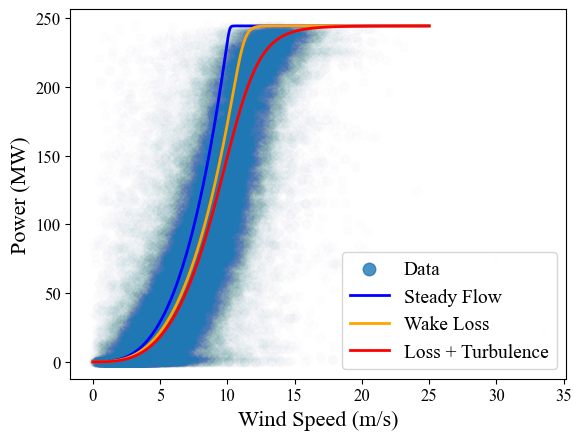

In [45]:
X = np.linspace(0, 25, 1000)
y_st = 163 * PLF5(X, 1.5, 0, -161.50069891, 10.15104929, 0.01857233)
y_wl = PLF5(X, 244.54466516, 0, -40.14553838, 11.21244215, 0.07457089)
y_lt = PLF5(X, 244.5, 0, -10.7, 11.5, 0.29)

plt.scatter(rnn['speed'], rnn['power'], alpha=0.006, label='Data')
plt.plot(X, y_st, label='Steady Flow', linewidth=2, color='blue')
plt.plot(X, y_wl, label='Wake Loss', linewidth=2, color='orange')
plt.plot(X, y_lt, label='Loss + Turbulence', linewidth=2, color='red')
plt.xlabel('Wind Speed (m/s)', fontsize=16)
plt.ylabel('Power (MW)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

leg = plt.legend(loc='lower right', fontsize=14, markerscale=1.5)
leg.legend_handles[0].set_alpha(0.8)

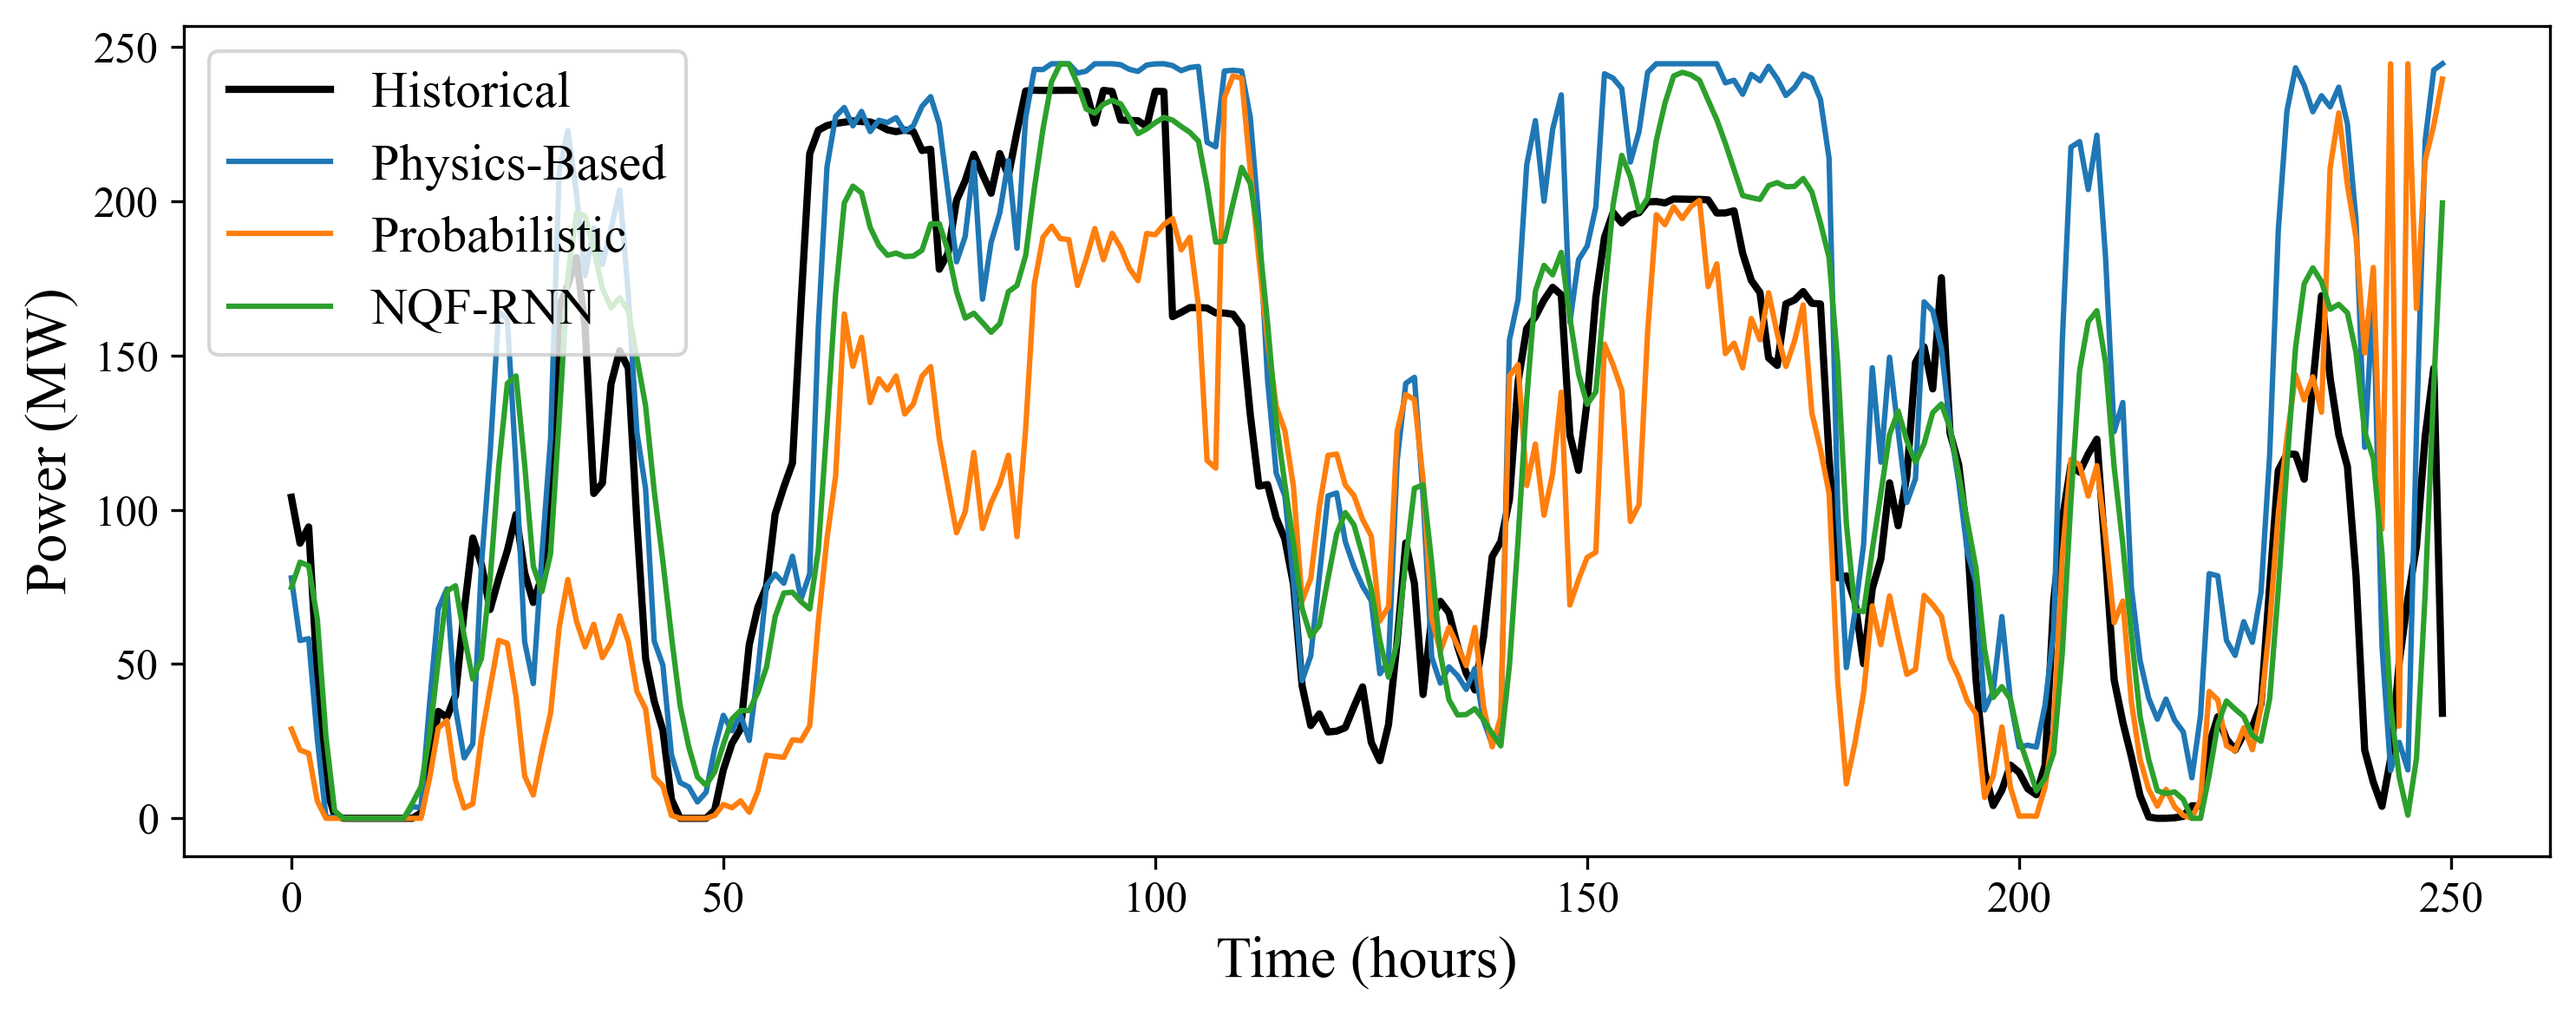

In [18]:
# time series
plt.figure(figsize=(10, 4), dpi=300)
plt.plot(rnn['power'][12000:12250].reset_index(drop=True), label='Historical', color='black', linewidth=2)
plt.plot(trad['preds'][12000:12250].reset_index(drop=True), label='Physics-Based')
plt.plot(prob['preds'][12000:12250].reset_index(drop=True), label='Probabilistic')
plt.plot(rnn['preds'][12000:12250].reset_index(drop=True), label='NQF-RNN')
plt.xlabel('Time (hours)', fontsize=16)
plt.ylabel('Power (MW)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left', fontsize=14)
plt.tight_layout()

# plt.savefig('../figures/nqfrnn_time_series.png', bbox_inches='tight', dpi=300)

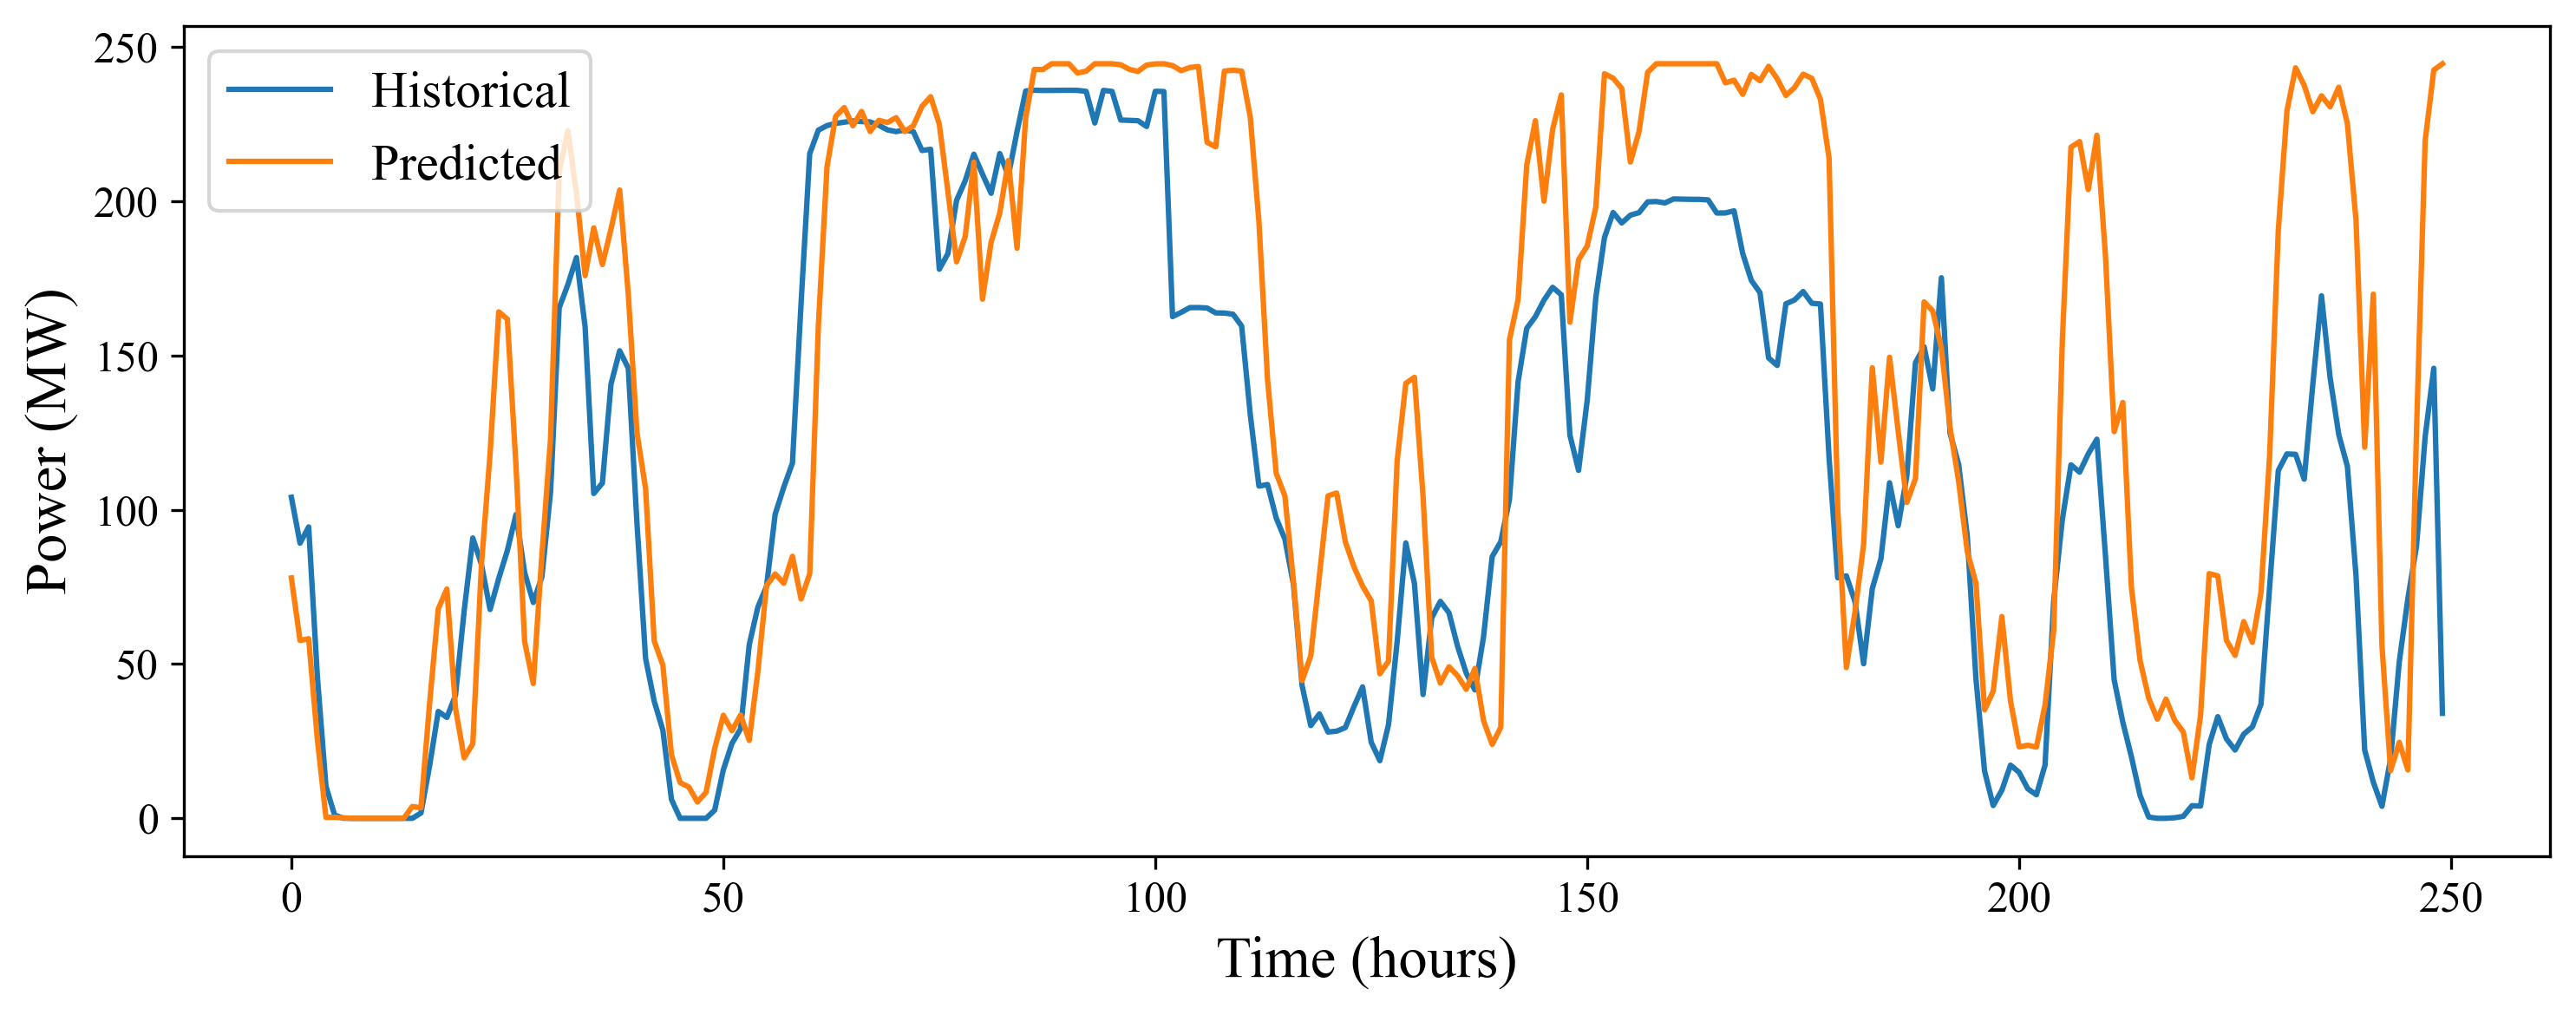

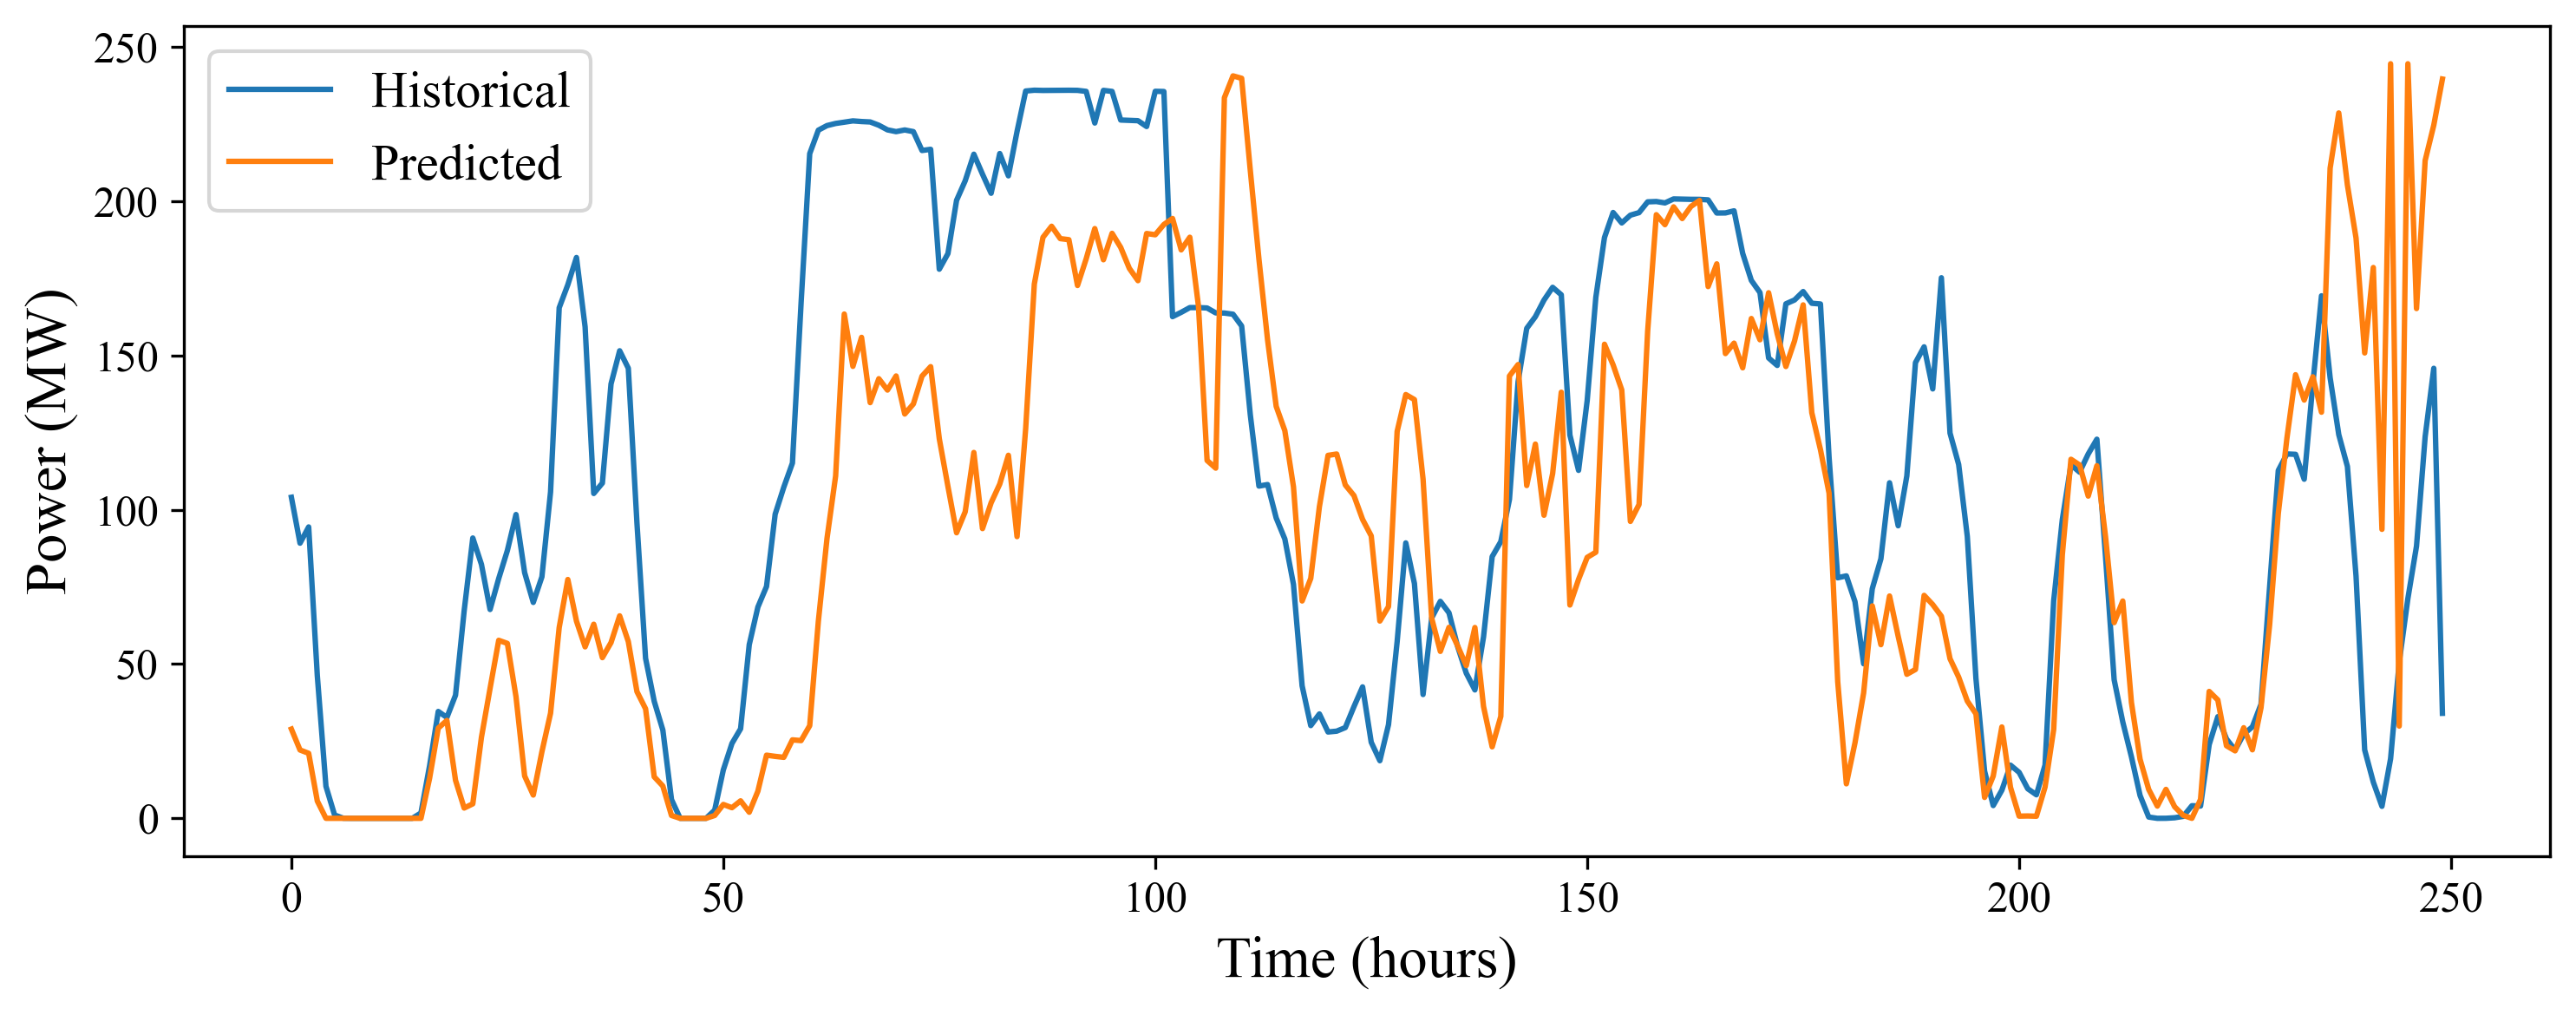

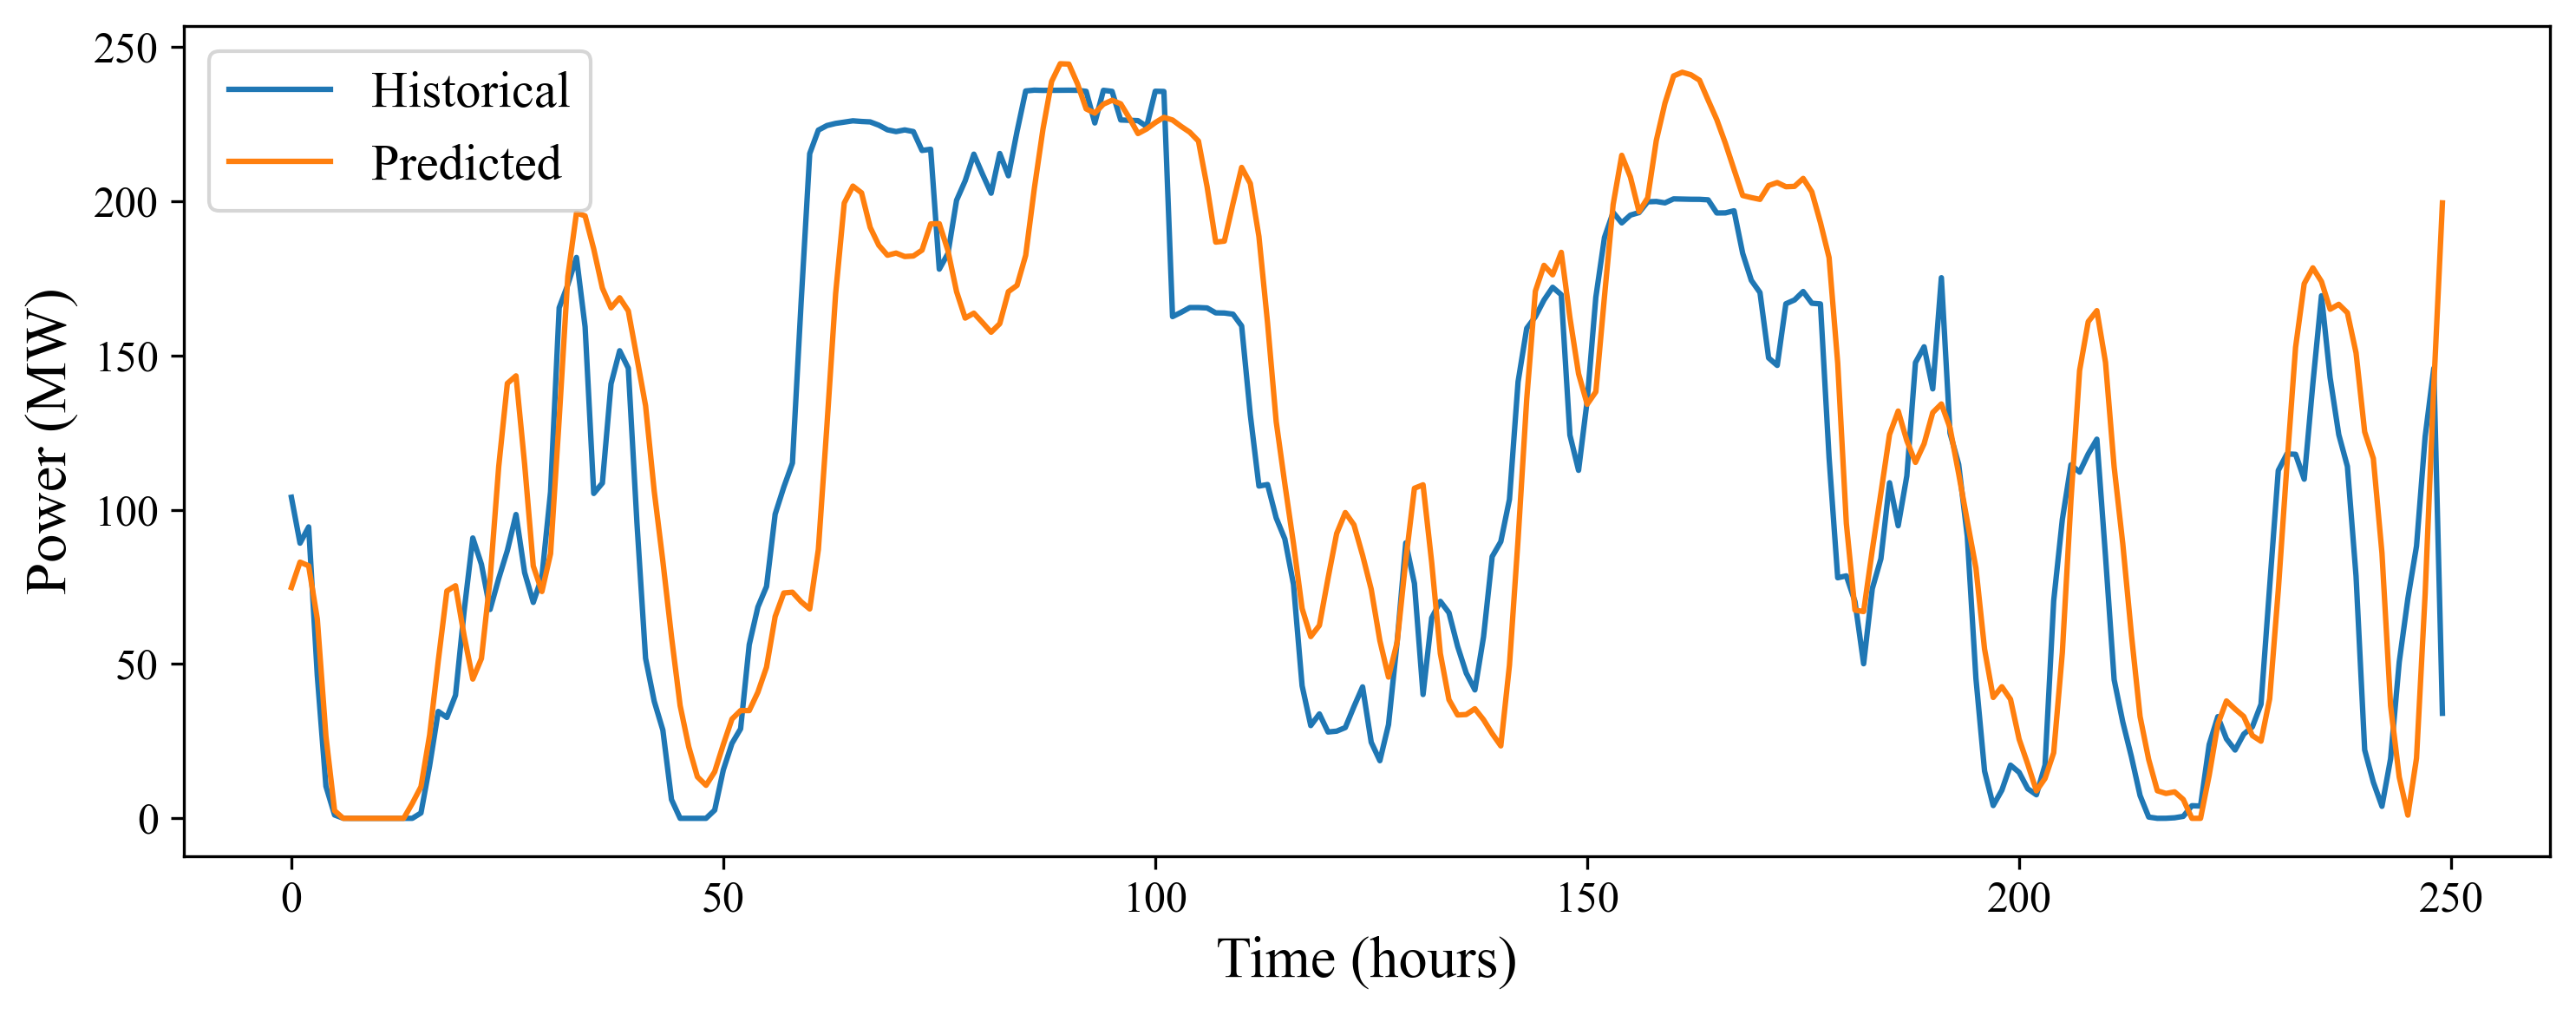

In [22]:
# time series
plt.figure(figsize=(10, 4), dpi=300)
plt.plot(rnn['power'][12000:12250].reset_index(drop=True), label='Historical')
plt.plot(trad['preds'][12000:12250].reset_index(drop=True), label='Predicted')
# plt.plot(prob['preds'][12000:12250].reset_index(drop=True), label='Probabilistic')
# plt.plot(rnn['preds'][12000:12250].reset_index(drop=True), label='NQF-RNN')
plt.xlabel('Time (hours)', fontsize=16)
plt.ylabel('Power (MW)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4), dpi=300)
plt.plot(rnn['power'][12000:12250].reset_index(drop=True), label='Historical')
plt.plot(prob['preds'][12000:12250].reset_index(drop=True), label='Predicted')
plt.xlabel('Time (hours)', fontsize=16)
plt.ylabel('Power (MW)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4), dpi=300)
plt.plot(rnn['power'][12000:12250].reset_index(drop=True), label='Historical')
plt.plot(rnn['preds'][12000:12250].reset_index(drop=True), label='Predicted')
plt.xlabel('Time (hours)', fontsize=16)
plt.ylabel('Power (MW)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
def plot_density_diff(df):
    H_true, _, _ = np.histogram2d(df['speed'], df['power'], bins=50)
    H_pred, _, _ = np.histogram2d(df['speed'], df['preds'], bins=50)
    vals_true = np.log(H_true.T)
    vals_true[np.isneginf(vals_true)] = 0
    vals_true = vals_true / vals_true.max()
    vals_pred = np.log(H_pred.T)
    vals_pred[np.isneginf(vals_pred)] = 0
    vals_pred = vals_pred / vals_pred.max()
    diff = vals_pred - vals_true

    # plot
    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(diff, origin='lower', cmap='bwr', vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)))
    ax.set_xlabel("Speed Bin", fontsize=16)
    ax.set_ylabel("Power Bin", fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=12)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Density Diff. (Pred - Hist)", fontsize=16)
    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout()
    plt.show()

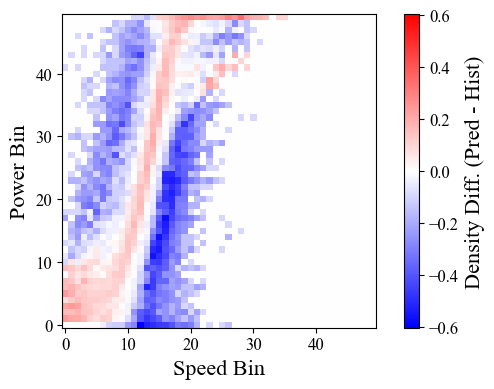

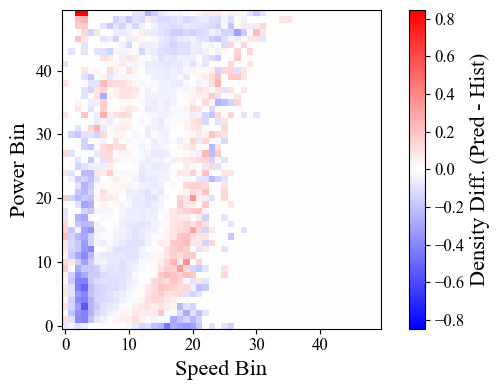

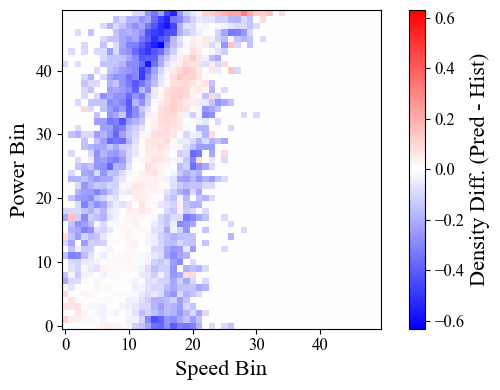

In [26]:
plot_density_diff(trad)
plot_density_diff(prob)
plot_density_diff(rnn)

In [71]:
def plot_density(df, name, hist=False, figsize=(6, 4)):
    H_true, _, _ = np.histogram2d(df['speed'], df['power'], bins=50)
    H_pred, _, _ = np.histogram2d(df['speed'], df['preds'], bins=50)

    # log transform
    vals_true = np.log(H_true.T)
    vals_true[np.isneginf(vals_true)] = 0
    vals_true = vals_true / vals_true.max()
    vals_pred = np.log(H_pred.T)
    vals_pred[np.isneginf(vals_pred)] = 0
    vals_pred = vals_pred / vals_pred.max()

    fig, axs = plt.subplots(figsize=figsize)
    if hist:
        bar = vals_true
        axs.imshow(vals_true, origin='lower', cmap='viridis')
        axs.set_title(f"{name} Density", fontsize=16)
    else:
        bar = vals_pred
        axs.imshow(vals_pred, origin='lower', cmap='viridis')
        axs.set_title(f"{name} Density", fontsize=16)

    axs.set_xlabel("Speed Bin", fontsize=16)
    axs.set_ylabel("Power Bin", fontsize=16)
    axs.tick_params(axis='both', which='major', labelsize=12)
    
    cbar = fig.colorbar(axs.imshow(bar, origin='lower', cmap='viridis'), ax=axs, orientation='vertical')
    cbar.set_label('Density', fontsize=16)
    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout()
    plt.show()

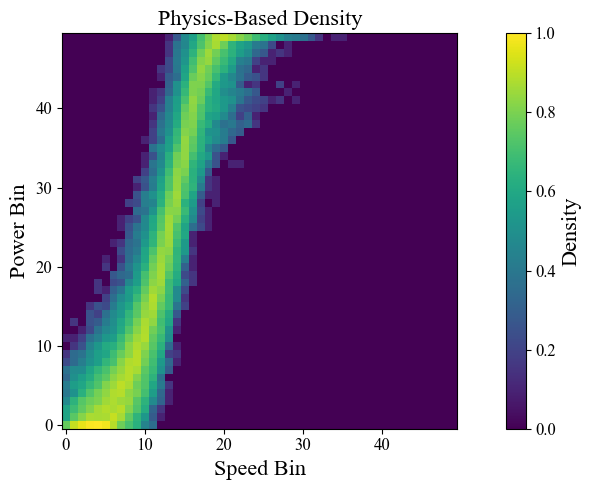

In [74]:
plot_density(trad, 'Physics-Based', figsize=(10, 5))

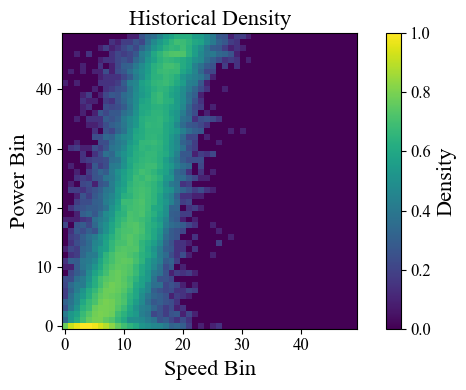

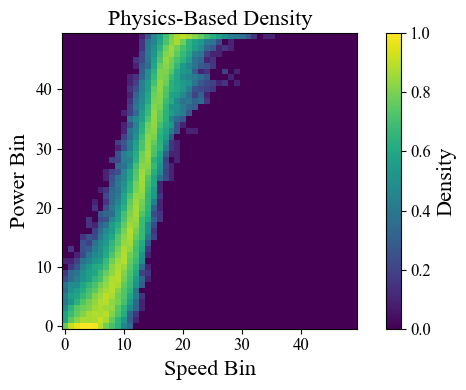

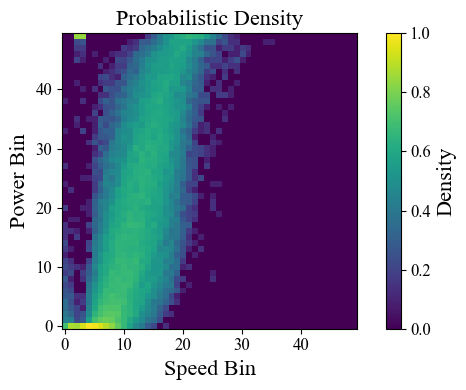

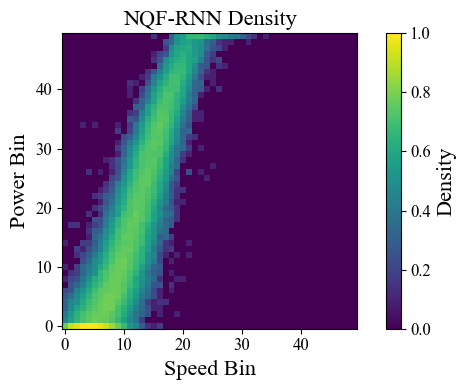

In [73]:
plot_density(trad, 'Historical', hist=True)
plot_density(trad, 'Physics-Based')
plot_density(prob, 'Probabilistic')
plot_density(rnn, 'NQF-RNN')

# Table 3

In [250]:
from scipy.optimize import curve_fit
from scipy.stats import weibull_min

In [184]:
def PLF5_cut(v, P, L, A, B, C, cut_in=3.5):
    base = L + (P - L) / (1 + (v / B) ** A) ** C
    return np.where(v < cut_in, 0, base)

def model(v, L, A, B, C):
    return PLF5_cut(v, 244.5, L, A, B, C, cut_in=3.5)

df_filtered = df[(df['power'] >= 5) | (df['speed'] <= 7)]

[10.71144726 -4.86777042 11.4212104   0.58874355]
[ 8.47574845 -5.88913873 11.73122532  0.47940434]


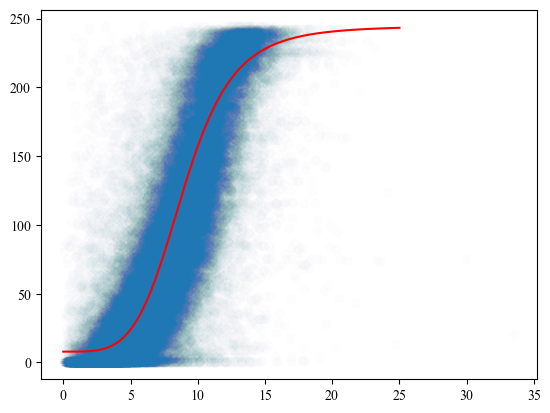

In [197]:
xdata = df["speed"].to_numpy()
ydata = df["power"].to_numpy()
p0 = [0, -10, 11, 0.2]

popt, pcov = curve_fit(model, xdata, ydata, p0=p0, maxfev=10000)
print(popt)

yhat = model(xdata, *popt)
sq_error = (yhat - ydata) ** 2
threshold = np.quantile(sq_error, 0.975)

df2 = df[sq_error < threshold]
xdata2 = df2["speed"].to_numpy()
ydata2 = df2["power"].to_numpy()
popt2, pcov2 = curve_fit(model, xdata2, ydata2, p0=p0, maxfev=10000)
print(popt2)

X = np.linspace(0, 25, 1000)
y_fit_lsq = PLF5(X, 244.5, 7.8817214, -5.2090740, 9.5720756, 0.7882193)
# y_fit_lsq = PLF5(X, 244.5 , *popt2)

plt.scatter(df['speed'], df['power'], alpha=0.006, label='Data')
plt.plot(X, y_fit_lsq, color='red')

In [198]:
df = rnn[['datetime', 'speed', 'power']]
df['steady_flow'] = 163 * PLF5(df['speed'], 1.5, 0, -161.50069891, 10.15104929, 0.01857233)
df['smoothed'] = PLF5(df['speed'], 244.5, 0, -10.7, 11.5, 0.29)
df['lsq'] = PLF5(df['speed'], 244.5, 7.8817214, -5.2090740, 9.5720756, 0.7882193)

In [199]:
i14 = 3678
i15 = 12378
i16 = 20992
i17 = 29716
i18 = 38476
i19 = 47236
i20 = 56020
i21 = 64780
i22 = 73540

In [204]:
power_years = pd.DataFrame({
    'Year': [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    'Raw': [int(df[:i14]['power'].sum()), int(df[i14:i15]['power'].sum()), int(df[i15:i16]['power'].sum()),
                    int(df[i16:i17]['power'].sum()), int(df[i17:i18]['power'].sum()), int(df[i18:i19]['power'].sum()),
                    int(df[i19:i20]['power'].sum()), int(df[i20:i21]['power'].sum()), int(df[i21:i22]['power'].sum()),
                    int(df[i22:]['power'].sum())],
    'Steady Flow': [int(df[:i14]['steady_flow'].sum()), int(df[i14:i15]['steady_flow'].sum()), int(df[i15:i16]['steady_flow'].sum()),
                    int(df[i16:i17]['steady_flow'].sum()), int(df[i17:i18]['steady_flow'].sum()), int(df[i18:i19]['steady_flow'].sum()),
                    int(df[i19:i20]['steady_flow'].sum()), int(df[i20:i21]['steady_flow'].sum()), int(df[i21:i22]['steady_flow'].sum()),
                    int(df[i22:]['steady_flow'].sum())],
    'Smoothed': [int(df[:i14]['smoothed'].sum()), int(df[i14:i15]['smoothed'].sum()), int(df[i15:i16]['smoothed'].sum()),
                    int(df[i16:i17]['smoothed'].sum()), int(df[i17:i18]['smoothed'].sum()), int(df[i18:i19]['smoothed'].sum()),
                    int(df[i19:i20]['smoothed'].sum()), int(df[i20:i21]['smoothed'].sum()), int(df[i21:i22]['smoothed'].sum()),
                    int(df[i22:]['smoothed'].sum())],
    'Least Sq': [int(df[:i14]['lsq'].sum()), int(df[i14:i15]['lsq'].sum()), int(df[i15:i16]['lsq'].sum()),
                    int(df[i16:i17]['lsq'].sum()), int(df[i17:i18]['lsq'].sum()), int(df[i18:i19]['lsq'].sum()),
                    int(df[i19:i20]['lsq'].sum()), int(df[i20:i21]['lsq'].sum()), int(df[i21:i22]['lsq'].sum()),
                    int(df[i22:]['lsq'].sum())]
})
power_years['Raw'] = (power_years['Raw'] / 1000).astype(int)
power_years['Steady Flow'] = (power_years['Steady Flow'] / 1000).astype(int)
power_years['Smoothed'] = (power_years['Smoothed'] / 1000).astype(int)
power_years['Least Sq'] = (power_years['Least Sq'] / 1000).astype(int)

power_years['SF %Diff'] = ((power_years['Steady Flow'] - power_years['Raw']) / power_years['Raw'] * 100).round(1)
power_years['Sm %Diff'] = ((power_years['Smoothed'] - power_years['Raw']) / power_years['Raw'] * 100).round(1)
power_years['Lsq %Diff'] = ((power_years['Least Sq'] - power_years['Raw']) / power_years['Raw'] * 100).round(1)

power_years.loc[10] = pd.Series({'Year': 'Total',
                    'Raw': int(power_years['Raw'].sum()),
                    'Steady Flow': int(power_years['Steady Flow'].sum()),
                    'Smoothed': int(power_years['Smoothed'].sum()),
                    'Least Sq': int(power_years['Least Sq'].sum()),
                    'SF %Diff': ((power_years['Steady Flow'].sum() - power_years['Raw'].sum()) / power_years['Raw'].sum() * 100).round(1),
                    'Sm %Diff': ((power_years['Smoothed'].sum() - power_years['Raw'].sum()) / power_years['Raw'].sum() * 100).round(1),
                    'Lsq %Diff': ((power_years['Least Sq'].sum() - power_years['Raw'].sum()) / power_years['Raw'].sum() * 100).round(1)})

In [207]:
power_years

,Year,Raw,Steady Flow,Smoothed,Least Sq,SF %Diff,Sm %Diff,Lsq %Diff
0,2014,296,430,324,342,45.3,9.5,15.5
1,2015,728,1066,799,842,46.4,9.8,15.7
2,2016,799,1082,815,856,35.4,2.0,7.1
3,2017,807,1071,800,846,32.7,-0.9,4.8
4,2018,793,1093,828,870,37.8,4.4,9.7
5,2019,786,1097,820,866,39.6,4.3,10.2
6,2020,799,1103,827,870,38.0,3.5,8.9
7,2021,753,976,717,770,29.6,-4.8,2.3
8,2022,769,1004,744,796,30.6,-3.3,3.5
9,2023,752,987,720,775,31.2,-4.3,3.1


# Prices and Revenue

In [240]:
prices = pd.read_csv('../../data/processed/18-21/lmp_2018-21.csv').drop(columns=['Unnamed: 0'])

In [241]:
prices.sort_values('datetime', inplace=True)
prices.reset_index(drop=True, inplace=True)
prices = pd.merge(prices, df[['datetime', 'speed', 'power']], on='datetime')

# discard prices higher than 1000
prices = prices[prices['lmp'] <= 1000]

In [248]:
bins = np.arange(0, 24, 1)
revdens = np.zeros(24)
for i in range(24):
    bin_data = prices[(prices['speed'] >= bins[i]) & (prices['speed'] < bins[i] + 1)]
    revdens[i] = (bin_data['lmp'] * bin_data['power']).sum() / len(bin_data)

In [251]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import SplineTransformer
from scipy.integrate import quad

In [254]:
cv_crit = []

X = prices[["speed"]].to_numpy()
y = prices["lmp"].to_numpy()

loo = LeaveOneOut()

In [259]:
for i in range(3, 14):  # df = 3:13
    print(i)
    model = make_pipeline(
        SplineTransformer(degree=3, n_knots=i, include_bias=False),
        LinearRegression()
    )
    # scikit-learn uses negative MSE, so flip sign
    scores = cross_val_score(model, X, y, cv=loo, scoring="neg_mean_squared_error")
    cv_crit.append(-scores.mean())

3


KeyboardInterrupt: 

In [261]:
# df_best = np.argmin(cv_crit) + 3  # +2 in R because loop starts at 3

# best_model = make_pipeline(
#     SplineTransformer(degree=3, n_knots=df_best, include_bias=False),
#     LinearRegression()
# )
# best_model.fit(X, y)

# def predict_price(x):
#     return best_model.predict(np.array(x).reshape(-1, 1))

shape, scale = 2.58309493, 8.38025919

# def price_exp(x):
#     return weibull_min.pdf(x, shape, scale=scale) * predict_price([x])[0] * PLF5(x, 244.4718239, -2.1593557, -10.9176942, 10.8237373, 0.2852041)

def price_exp2(x):
    return weibull_min.pdf(x, shape, scale=scale) * np.mean(prices["lmp"]) * PLF5(x, 244.4718239, -2.1593557, -10.9176942, 10.8237373, 0.2852041)

# def price_exp3(x):
#     return weibull_min.pdf(x, shape, scale=scale) * predict_price([x])[0] * 163 * PLF5(x, 1.5, -0.02181750, -161.50069891, 10.15104929, 0.01857233)

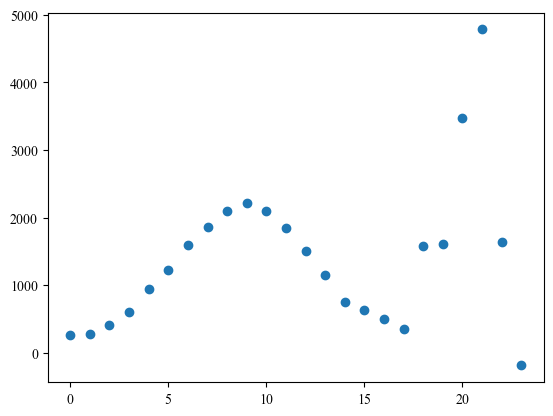

In [249]:
plt.scatter(bins, revdens)

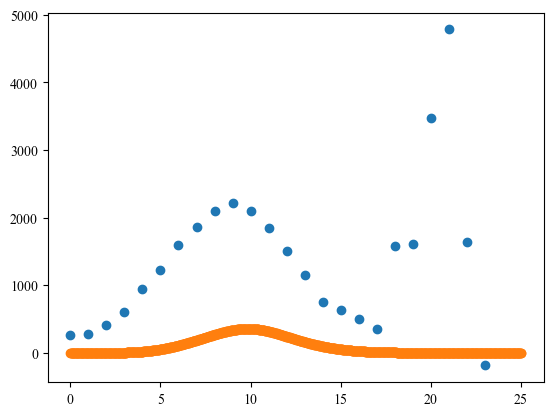

In [263]:
x = np.linspace(0, 25, 1000)
mean_price = price_exp2(x)
# spline_price = price_exp(x)

plt.scatter(bins, revdens)
plt.scatter(x, mean_price, label='Mean Price')

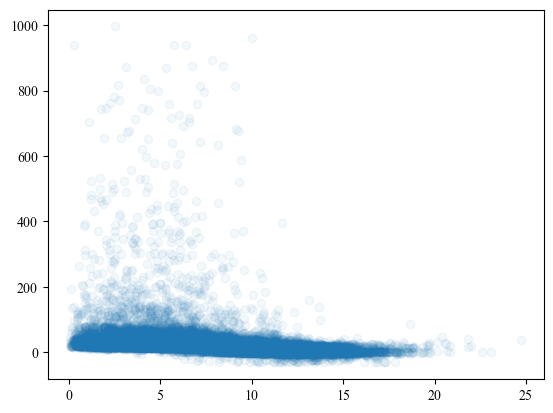

In [242]:
plt.scatter(prices['speed'], prices['lmp'], alpha=0.05)